# Binder Design Pipeline
MH - 10/01/2026
```
RFD3 → MPNN → RF3
```

This notebook contains the computational design tools to generate de novo TCR sequences that bind to the influenza GIL peptide.

and analysis of protein binders targeting the extracellular domain of the heterodimeric class-B GPCR complex CLR:RAMP1. The goal is to design antagonistic binders that engage the receptor complex and block ligand-induced activation.

### Kernel Instructions
This notebook is designed to run in the `cgrp_env1` Conda environment, which already contains all required packages. You only need to register this environment as a Jupyter kernel once.

```
conda env create -f binder.yml
conda activate cgrp_env1
python -m ipykernel install --user \
  --name cgrp_env1 \
  --display-name "binder_design"
```
Then, in Jupyter, select:
```
Kernel → binder_design
```
After that, you can run all cells in this notebook normally. You may need to restart your IDE if it does not show up immediately.

### Set Up: imports and directories

In [ ]:
# --- Core ---
import os, sys, re, glob, json, math, time, ast, stat, shutil, random, string, tempfile, warnings, subprocess, csv, shlex
import itertools
from pathlib import Path
from collections import Counter, defaultdict, OrderedDict
from datetime import datetime
from difflib import SequenceMatcher
from copy import deepcopy

# --- Data / numerics ---
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

# --- Plotting ---
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import to_rgba, ListedColormap, LinearSegmentedColormap
import seaborn as sns

# --- BioPython ---
from Bio import SeqIO, PDB
from Bio.PDB import PDBParser, PPBuilder

# --- Notebook display ---
from IPython.display import display, HTML

# --- Shared utilities ---
import jupyter_utils

In [ ]:
user        = os.environ.get('USER', '')
campaign    = 'CLR_RAMP1'  # target / receptor name
experiment  = 'exp_01'     # experiment / round identifier
display_all = True         # set False to revert to default pandas display settings

working_dir = f'/work3/{user}/projects/binder_design/{campaign}/{experiment}'
os.makedirs(working_dir, exist_ok=True)
os.chdir(working_dir)

def setup_directories(base_dir, dirs_list):
    """Create subdirectories and return a dict mapping <name>_dir → full path."""
    result = {}
    for dir_name in dirs_list:
        full_path = os.path.join(base_dir, dir_name)
        os.makedirs(full_path, exist_ok=True)
        result[dir_name + '_dir'] = full_path
    return result

wrk_dirs_list = ['cmds', 'submit', 'logs', 'cute_pics', 'configs', 'scores', 'inputs',
                 'diffusion_out', 'rf3_out', 'mpnn_out']
_dirs = setup_directories(working_dir, wrk_dirs_list)

cmds_dir          = _dirs['cmds_dir']
submit_dir        = _dirs['submit_dir']
logs_dir          = _dirs['logs_dir']
cute_pics_dir     = _dirs['cute_pics_dir']
configs_dir       = _dirs['configs_dir']
scores_dir        = _dirs['scores_dir']
inputs_dir        = _dirs['inputs_dir']
diffusion_out_dir = _dirs['diffusion_out_dir']
rf3_out_dir       = _dirs['rf3_out_dir']
mpnn_out_dir      = _dirs['mpnn_out_dir']

if display_all:
    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_colwidth', None)
else:
    pd.reset_option('display.max_columns')
    pd.reset_option('display.max_rows')
    pd.reset_option('display.max_colwidth')

print(f"Campaign : {campaign} / {experiment}")
print(f"Directory: {working_dir}")

### RFD3

RFdiffusion3 (RFD3) generates de novo binder backbone structures by diffusing from noise while steering the design toward your target residues. Hotspots guide where the binder contacts the target; the contig defines how many residues to design and which target chains to include.

Full parameter reference: [RFD3 protein binder design docs](https://github.com/RosettaCommons/foundry/blob/production/models/rfd3/docs/protein_binder_design.md)

Key parameters to configure below:
- **`contig`**: free range (e.g. `50-150`) sets binder length; fixed segments like `B33-54` copy target residues from the input PDB into the design context. `/0` separates chains.
- **`select_hotspots`**: atom-level target residues the binder should contact — drives where RFD3 places the binder.
- **`select_hbond_donor/acceptor`**: optionally steer RFD3 to form H-bonds with specific target atoms.
- **`infer_ori_strategy`**: `"hotspots"` places the binder origin relative to the hotspot centroid (recommended for binder design).

#### Make jsons

In [ ]:
design_name = "CLR_RAMP1_test"
dialect     = 2
input_pdb   = f'{inputs_dir}/6e3y_cut.pdb'  # path to your input structure

# Binder length (free range) + fixed target residue segments; /0 separates chains
contig = "50-150,/0,B33-54,10,B64-106,3,B110-200,/0,C29-120"

# Total design length range (binder residues + fixed target residues)
length = "298-398"

redesign_motif_sidechains = False
json_name = "CLR_RAMP1_rfd3_test.json"

# Residues on the target the binder should contact (atom-level)
select_hotspots = {
    "B33": "NE2",
    "B72": "NE1,CD1,CD2,CG,CE3,CZ2,CZ3",
    "B92": "CD2,CD1,CE1,CE2,CZ",
}
# Optionally guide H-bond formation with specific target atoms
select_hbond_donor = {
    "B38": "NH1,NH2",
}
select_hbond_acceptor = {
    "B90": "OD1,OD2",
    "B94": "OD1,OD2",
}

infer_ori_strategy = "hotspots"  # places binder origin relative to hotspot positions
is_non_loopy       = True         # biases diffusion toward helices; reduces loop content

# Output JSON path
rfd3_json = str(Path(configs_dir) / json_name)
# ------------------------------

payload = {
    design_name: {
        "dialect": dialect,
        "input": input_pdb,
        "contig": contig,
        "length": length,
        "redesign_motif_sidechains": redesign_motif_sidechains,
        "select_hotspots": select_hotspots,
        "select_hbond_donor": select_hbond_donor,
        "select_hbond_acceptor": select_hbond_acceptor,
        "infer_ori_strategy": infer_ori_strategy,
        "is_non_loopy": is_non_loopy
    }
}

out_path = Path(rfd3_json)
out_path.parent.mkdir(parents=True, exist_ok=True)

with out_path.open("w") as f:
    json.dump(payload, f, indent=4)

print(f"Wrote JSON → {out_path}")

#### Generate submit.sh

In [ ]:
# ---------------- CONFIG (edit these) ---------------- #
queue        = "cabl40s"
job_name     = "rfd3"
cores        = 4
gpu_spec     = 'num=1:mode=exclusive_process'
time_limit   = "12:00"
mem          = "10GB"
INPUT_JSON   = rfd3_json
OUT_DIR      = diffusion_out_dir
CKPT_PATH    = "/dtu/projects/dbl/foundry/ckpt/rfd3_latest.ckpt"

diffusion_batch_size = 2
n_batches = 2

script_path = os.path.join(submit_dir, f"{job_name}.sh")
# ------------------------------------------------------- #

script = f"""#!/bin/sh
#BSUB -q {queue}
#BSUB -J {job_name}
#BSUB -n {cores}
#BSUB -gpu "{gpu_spec}"
#BSUB -W {time_limit}
#BSUB -R "rusage[mem={mem}]"
#BSUB -R "span[hosts=1]"
#BSUB -o {logs_dir}/%J.out
#BSUB -e {logs_dir}/%J.err

mkdir -p {logs_dir}
module load cuda/12.4
source /dtu/projects/dbl/foundry/miniforge3/etc/profile.d/conda.sh
conda activate /dtu/projects/dbl/foundry/miniforge3/envs/rfd3

export RFD3_PATH="/dtu/projects/dbl/foundry"
export PYTHONPATH="${{RFD3_PATH}}:${{PYTHONPATH:-}}"

mkdir -p "{OUT_DIR}"
echo "Output directory: {OUT_DIR}"

rfd3 design \\
    out_dir="{OUT_DIR}" \\
    inputs="{INPUT_JSON}" \\
    ckpt_path="{CKPT_PATH}" \\
    diffusion_batch_size={diffusion_batch_size} \\
    n_batches={n_batches} \\
    inference_sampler.step_scale=3 \\
    inference_sampler.gamma_0=0.2

echo "Completed at $(date)"
"""

with open(script_path, "w") as f:
    f.write(script)

print(f"Wrote submit script → {script_path}")
print(f"\nSubmit with:\n  bsub < {script_path}\n")

#### Process rfd3 outputs

In [ ]:
json_rfd3_dir    = diffusion_out_dir
rfd3_metrics_csv = Path(scores_dir) / "rfd3_metrics_with_json_path.csv"
# -----------------------------

json_paths = sorted(glob.glob(os.path.join(json_rfd3_dir, "*.json")))
if not json_paths:
    raise SystemExit(f"No JSON files found in {json_rfd3_dir!r} — run RFD3 jobs first.")

rows = []
all_keys = set(["json_path"])

for jp in json_paths:
    with open(jp, "r") as f:
        data = json.load(f)

    metrics = data.get("metrics", {})
    row = {"json_path": os.path.abspath(jp)}
    for k, v in metrics.items():
        if k in ("diffused_com", "fixed_com") and isinstance(v, (list, tuple)) and len(v) == 3:
            row[f"{k}_x"], row[f"{k}_y"], row[f"{k}_z"] = v
            all_keys.update({f"{k}_x", f"{k}_y", f"{k}_z"})
        else:
            row[k] = v
            all_keys.add(k)
    rows.append(row)

fieldnames = ["json_path"] + sorted(k for k in all_keys if k != "json_path")

with open(rfd3_metrics_csv, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for r in rows:
        writer.writerow(r)

print(f"Wrote {len(rows)} rows → {rfd3_metrics_csv}")
print("Columns:", fieldnames)

In [ ]:
df = pd.read_csv(rfd3_metrics_csv)
df.head(10)

Plotting: ['alanine_content', 'glycine_content', 'helix_fraction', 'loop_fraction', 'sheet_fraction', 'max_ca_deviation', 'n_chainbreaks', 'n_clashing.interresidue_clashes_w_backbone', 'n_clashing.interresidue_clashes_w_sidechain', 'non_loop_fraction', 'radius_of_gyration']


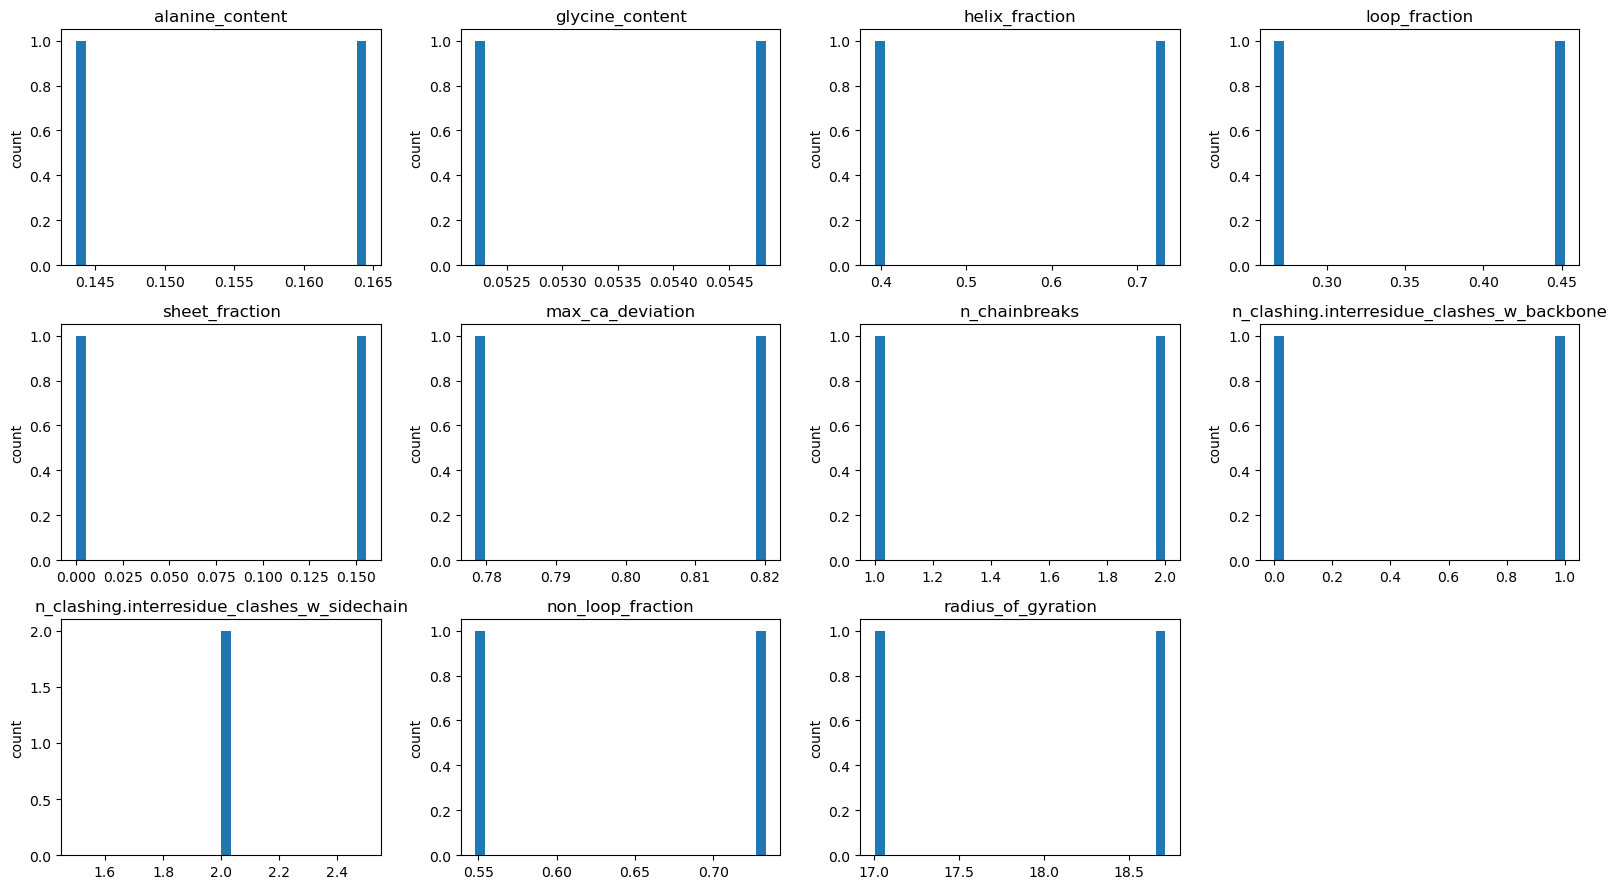

In [64]:
metrics = [
    "alanine_content",
    "glycine_content",
    "helix_fraction",
    "loop_fraction",
    "sheet_fraction",
    "max_ca_deviation",
    "n_chainbreaks",
    "n_clashing.interresidue_clashes_w_backbone",
    "n_clashing.interresidue_clashes_w_sidechain",
    "non_loop_fraction",
    "radius_of_gyration",
]

# Keep only columns that exist (safety)
metrics = [m for m in metrics if m in df.columns]

print("Plotting:", metrics)

n_metrics = len(metrics)
n_cols = 4
n_rows = math.ceil(n_metrics / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

def plot_hist(ax, series, title):
    s = series.dropna()
    if s.empty:
        ax.set_title(f"{title} (no data)")
        ax.axis("off")
        return
    ax.hist(s, bins=30)
    ax.set_title(title)
    ax.set_ylabel("count")

for ax, col in zip(axes, metrics):
    plot_hist(ax, df[col], col)

# Turn off unused axes
for ax in axes[len(metrics):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

##### Optional: Copy filtered .cif.gz in a subfolder (loop content)

In [67]:
df_filt = df[
    (df["loop_fraction"] < 0.4) &
    (df["non_loop_fraction"] > 0.6)
].copy()

print(f"Total designs: {len(df)}")
print(f"Passing designs: {len(df_filt)}")

df_filt.head()

Total designs: 2
Passing designs: 1


,json_path,alanine_content,diffused_com_x,diffused_com_y,diffused_com_z,fixed_com_x,fixed_com_y,fixed_com_z,glycine_content,helix_fraction,loop_fraction,max_ca_deviation,n_chainbreaks,n_clashing.interresidue_clashes_w_backbone,n_clashing.interresidue_clashes_w_sidechain,non_loop_fraction,num_residues,num_ss_elements,radius_of_gyration,sheet_fraction
1,/work3/marhr/Projects/dbl/binder_design_pipeline/CLR_RAMP1/exp_01/diffusion_out/CLR_RAMP1_rfd3_test_CLR_RAMP1_test_0_model_1.json,0.143603,-1.690963,-4.120264,-0.641365,10.650076,-3.605643,-12.054029,0.05483,0.733333,0.266667,0.77843,1,0,2,0.733333,383,6,18.711447,0.0


In [74]:
from pathlib import Path
import shutil
import os

PATH_COL = "json_path"
filter_name = "passing_loop_nonloop"

filtered_dir = Path(diffusion_out_dir) / filter_name
filtered_dir.mkdir(parents=True, exist_ok=True)

def copy_design(json_path: str, dst_dir: Path) -> int:
    """Copy one design's JSON and its matching CIF/CIF.GZ (same stem) into dst_dir."""
    jp = Path(json_path)
    if not jp.exists():
        return 0

    copied = 0

    # Copy JSON itself
    dst_json = dst_dir / jp.name
    if not dst_json.exists():
        shutil.copy2(jp, dst_json)
        copied += 1

    # Copy matching CIF (same stem) from the same directory as the JSON
    stem = jp.stem  # "design_0001" from "design_0001.json"
    candidates = [jp.with_name(stem + ".cif"), jp.with_name(stem + ".cif.gz")]

    for cif in candidates:
        if cif.exists():
            dst_cif = dst_dir / cif.name
            if not dst_cif.exists():
                shutil.copy2(cif, dst_cif)
                copied += 1

    return copied

total_copied = 0
missing = 0

unique_paths = df_filt[PATH_COL].dropna().unique()
print("Passing designs:", len(unique_paths))

for p in unique_paths:
    if not isinstance(p, str) or not os.path.exists(p):
        print(f"[MISSING] {p}")
        missing += 1
        continue
    total_copied += copy_design(p, filtered_dir)

print(f"Copied files: {total_copied}")
print(f"Missing paths: {missing}")
print(f"Output folder: {filtered_dir}")

Passing designs: 1
Copied files: 0
Missing paths: 0
Output folder: /work3/marhr/Projects/dbl/binder_design_pipeline/CLR_RAMP1/exp_01/diffusion_out/passing_loop_nonloop


### MPNN

ProteinMPNN designs amino acid sequences onto each generated backbone. For binder design, the entire binder chain is redesigned freely — no residues need to be fixed.

In [ ]:
seed              = 42
batch_size        = 5    # sequences per structure
number_of_batches = 1    # total sequences per design = batch_size × number_of_batches
ckpt              = '/dtu/projects/dbl/LigandMPNN/25.3.1-0//model_params/proteinmpnn_v_48_020.pt'
chains_to_design  = 'A'  # binder chain to redesign

In [ ]:
cmds = f'{cmds_dir}/mpnn.cmds'

with open(cmds, 'w') as f:
    for structure in sorted(glob.glob(f'{diffusion_out_dir}/*/*cif.gz')):
        bn = os.path.basename(structure).replace('.cif.gz', '').replace('.pdb', '')
        this_outdir = f'{mpnn_out_dir}/{bn}'
        os.makedirs(this_outdir, exist_ok=True)

        cmd = f'python /dtu/projects/dbl/LigandMPNN/25.3.1-0/run.py \
                --seed {seed} \
                --pdb_path "{structure}" \
                --out_folder "{this_outdir}" \
                --batch_size {batch_size} \
                --number_of_batches {number_of_batches} \
                --model_type "protein_mpnn" \
                --checkpoint_protein_mpnn "{ckpt}" \
                --chains_to_design "{chains_to_design}" '
        f.write(cmd + '\n')

n_tasks = len(open(cmds).readlines())
jupyter_utils.make_sub_script(cmds, n_task=n_tasks, group_size=10, mem='10G', queue='hpc',
                              job_name='mpnn', cores=4, time_limit='2:00',
                              python_path='/dtu/projects/dbl/LigandMPNN/25.3.1-0/',
                              env='/dtu/projects/dbl/LigandMPNN/25.3.1-0//miniforge3/envs/ligandmpnn_env')

sub_script = cmds.replace('.cmds', '.sh')
print(f"Generated {n_tasks} MPNN job(s).")
print(f"\nSubmit with:\n  bsub < {sub_script}\n")

### RF3
In the CLR:RAMP1 design campaign, the target complex consists of two chains (F and G), while the designed binder is assumed to be chain A. Each RF3 JSON is therefore generated from a single sequence in the MPNN FASTA files.

The script iterates over all sequences in each FASTA file and applies optional filters (for example, a maximum arginine content filter), skipping any sequences that do not pass. The first sequence without an id= tag (the original RFD3 design) is also ignored.

All passing sequences are written as individual RF3 JSON files, which are saved in configs/rf3.

#### Generate rf3 jsons

In [ ]:
mpnn_root = mpnn_out_dir

# rf3_template.json defines the target chains (F, G) that remain fixed in all RF3 runs.
# Place this file in configs/ before running — copy from a previous campaign if needed.
rf3_template_path = f'{configs_dir}/rf3_template.json'

rf3_json_dir = Path(configs_dir) / "rf3"
rf3_json_dir.mkdir(parents=True, exist_ok=True)

MAX_R_PER_200  = None   # e.g. 4.0 to filter high-arginine sequences; None to disable
ONLY_IDS_1_TO_9 = False
# ----------------------------------------

ID_RE = re.compile(r"(?:^|[, ])id=(\d+)(?:,|$)")

def parse_fasta(path):
    header = None
    seq_chunks = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(seq_chunks)
                header = line[1:].strip()
                seq_chunks = []
            else:
                seq_chunks.append(line)
        if header is not None:
            yield header, "".join(seq_chunks)

def extract_id(header: str):
    m = ID_RE.search(header)
    return int(m.group(1)) if m else None

def chain_a(seq: str) -> str:
    return seq.split(":", 1)[0]

def r_per_200(seq: str) -> float:
    L = len(seq)
    return 0.0 if L == 0 else (seq.count("R") / L) * 200.0

if not os.path.isdir(mpnn_root):
    raise FileNotFoundError(f"mpnn_root does not exist: {mpnn_root}")
if not os.path.isfile(rf3_template_path):
    raise FileNotFoundError(f"rf3_template_path does not exist: {rf3_template_path}")

with open(rf3_template_path) as f:
    template = json.load(f)

if "components" not in template or not isinstance(template["components"], list):
    raise ValueError("RF3 template must contain a top-level 'components' list.")

template_name = template.get("name", "")

binder_idx = None
for i, comp in enumerate(template["components"]):
    if isinstance(comp, dict) and comp.get("chain_id") == "A" and "seq" in comp:
        binder_idx = i
        break
if binder_idx is None:
    raise ValueError("Could not find binder component with {'chain_id': 'A', 'seq': ...} in the RF3 template.")

fa_files = sorted(glob.glob(os.path.join(mpnn_root, "**", "seqs", "*.cif.gz.fa"), recursive=True))

total_records = total_written = 0
skipped_no_id = skipped_fail = skipped_ids = 0

for fa_path in fa_files:
    model_dir = os.path.basename(os.path.dirname(os.path.dirname(fa_path)))

    for header, seq in parse_fasta(fa_path):
        total_records += 1
        seq_id = extract_id(header)

        if seq_id is None:
            skipped_no_id += 1
            continue

        if ONLY_IDS_1_TO_9 and not (1 <= seq_id <= 9):
            skipped_ids += 1
            continue

        a = chain_a(seq)

        if MAX_R_PER_200 is not None and r_per_200(a) > float(MAX_R_PER_200):
            skipped_fail += 1
            continue

        j = deepcopy(template)
        j["components"][binder_idx]["seq"] = a

        safe_model = model_dir
        if template_name and safe_model.startswith(template_name):
            safe_model = safe_model[len(template_name):].lstrip("_")

        name = f"{safe_model}__id{seq_id}"
        j["name"] = name

        out_path = rf3_json_dir / f"{name}.json"
        with open(out_path, "w") as out_f:
            json.dump(j, out_f, indent=4)

        total_written += 1

print(f"FASTA files scanned   : {len(fa_files)}")
print(f"Total FASTA records   : {total_records}")
print(f"Skipped (no id=...)   : {skipped_no_id}")
print(f"Skipped (ID filter)   : {skipped_ids}")
print(f"Skipped (R filter)    : {skipped_fail}")
print(f"JSONs written         : {total_written}")
print(f"Output dir            : {rf3_json_dir}")

#### Create cmds

In [87]:
cmds_path = os.path.join(cmds_dir, "rf3_cmds")
ckpt_path = "/dtu/projects/dbl/rf3/release/ckpt/rf3_latest.pt"
num_steps = 50
# --------------------------------------

json_files = sorted(Path(rf3_json_dir).glob("*.json"))

if not json_files:
    raise RuntimeError(f"No JSON files found in {rf3_json_dir}")

lines = []

for jf in json_files:
    name = jf.stem
    out_dir = os.path.join(rf3_out_dir, name)

    cmd = (
        "rf3 fold "
        "inference_engine=rf3 "
        f"inputs={jf} "
        f"out_dir={out_dir} "
        f"ckpt_path={ckpt_path} "
        f"num_steps={num_steps} "
        "annotate_b_factor_with_plddt=True "
        "early_stopping_plddt_threshold=0"
    )

    lines.append(cmd)

with open(cmds_path, "w") as f:
    f.write("\n".join(lines))

print(f"✓ Wrote {len(lines)} commands to:")
print(cmds_path)
print("\nFirst 3 commands:\n")
for l in lines[:3]:
    print(l)

✓ Wrote 5 commands to:
/work3/marhr/Projects/dbl/binder_design_pipeline/CLR_RAMP1/exp_01/cmds/rf3_cmds

First 3 commands:

rf3 fold inference_engine=rf3 inputs=/work3/marhr/Projects/dbl/binder_design_pipeline/CLR_RAMP1/exp_01/configs/rf3/CLR_RAMP1_rfd3_test_CLR_RAMP1_test_0_model_1__id1.json out_dir=/work3/marhr/Projects/dbl/binder_design_pipeline/CLR_RAMP1/exp_01/rf3_out/CLR_RAMP1_rfd3_test_CLR_RAMP1_test_0_model_1__id1 ckpt_path=/dtu/projects/dbl/rf3/release/ckpt/rf3_latest.pt num_steps=50 annotate_b_factor_with_plddt=True early_stopping_plddt_threshold=0
rf3 fold inference_engine=rf3 inputs=/work3/marhr/Projects/dbl/binder_design_pipeline/CLR_RAMP1/exp_01/configs/rf3/CLR_RAMP1_rfd3_test_CLR_RAMP1_test_0_model_1__id2.json out_dir=/work3/marhr/Projects/dbl/binder_design_pipeline/CLR_RAMP1/exp_01/rf3_out/CLR_RAMP1_rfd3_test_CLR_RAMP1_test_0_model_1__id2 ckpt_path=/dtu/projects/dbl/rf3/release/ckpt/rf3_latest.pt num_steps=50 annotate_b_factor_with_plddt=True early_stopping_plddt_thresho

#### Submit rf3 jobs

In [102]:
# ---------------- CONFIG ----------------
job_name    = "rf3"
queue       = "gpua100"         # or "cabl40s"
time_limit  = "12:00"
mem_per_job = "10GB"
gpus        = 'num=1:mode=exclusive_process'
cores       = 4
group_size  = 20                # commands per array index

rf3_release = "/dtu/projects/dbl/rf3/release"
ckpt_path   = "/dtu/projects/dbl/rf3/release/ckpt/rf3_latest.pt"
num_steps   = 50
# ----------------------------------------

# Create dirs
for d in (logs_dir, cmds_dir, submit_dir, rf3_out_dir):
    Path(d).mkdir(parents=True, exist_ok=True)

rf3_json_dir = Path(rf3_json_dir)
json_files = sorted(rf3_json_dir.glob("*.json"))
if not json_files:
    raise RuntimeError(f"No JSON files found in {rf3_json_dir}")

# -------- write command file (no .txt) --------
cmds_path = Path(cmds_dir) / "rf3_cmds"

lines = []
for jf in json_files:
    stem = jf.stem
    out_dir = Path(rf3_out_dir) / stem

    # Keep this minimal; environment setup goes in the LSF script
    cmd = (
        "module load cuda/12.4 && "
        f"export RF3_PATH={shlex.quote(rf3_release)} && "
        f"source {shlex.quote(os.path.join(rf3_release, 'activate_env.sh'))} && "
        "export PYTHONPATH=\"${RF3_PATH}:${PYTHONPATH:-}\" && "
        "rf3 fold "
        "inference_engine=rf3 "
        f"inputs={jf} "
        f"out_dir={out_dir} "
        f"ckpt_path={ckpt_path} "
        f"num_steps={num_steps} "
        "annotate_b_factor_with_plddt=True "
        "early_stopping_plddt_threshold=0"
    )
    lines.append(cmd)

cmds_path.write_text("\n".join(lines) + "\n")
print(f"✓ Wrote {len(lines)} commands → {cmds_path}")

# -------- write LSF array script --------
num_jobs = math.ceil(len(lines) / group_size)
script_path = Path(submit_dir) / f"{job_name}.lsf"

lsf = f"""#!/bin/sh
#BSUB -q {queue}
#BSUB -J "{job_name}[1-{num_jobs}]"
#BSUB -n {cores}
#BSUB -R "span[hosts=1]"
#BSUB -gpu "{gpus}"
#BSUB -W {time_limit}
#BSUB -R "rusage[mem={mem_per_job}]"
#BSUB -B
#BSUB -N
#BSUB -o {logs_dir}/rf3%J.out
#BSUB -e {logs_dir}/rf3%J.err

set -euo pipefail

GROUP_SIZE={group_size}
CMD_FILE="{cmds_path}"

FIRST=$(( ($LSB_JOBINDEX - 1) * GROUP_SIZE + 1 ))
LAST=$(( $LSB_JOBINDEX * GROUP_SIZE ))

i=$FIRST
while [ $i -le $LAST ]; do
    CMD=$(sed -n "${{i}}p" "$CMD_FILE" || true)
    if [ -z "$CMD" ]; then
        break
    fi
    echo "[${{LSB_JOBID}},${{LSB_JOBINDEX}}] Running command #${{i}}"
    bash -lc "$CMD"
    i=$((i+1))
done

echo "Done array index $LSB_JOBINDEX."
"""

script_path.write_text(lsf)
script_path.chmod(0o755)

print(f"✓ Wrote LSF array script → {script_path}")
print("Submit with:")
print(f"  bsub < {script_path}")
print("\nFirst 3 commands:\n" + "".join(f"{i+1}. {lines[i]}\n" for i in range(min(3, len(lines)))))

✓ Wrote 5 commands → /work3/marhr/Projects/dbl/binder_design_pipeline/CLR_RAMP1/exp_01/cmds/rf3_cmds
✓ Wrote LSF array script → /work3/marhr/Projects/dbl/binder_design_pipeline/CLR_RAMP1/exp_01/submit/rf3.lsf
Submit with:
  bsub < /work3/marhr/Projects/dbl/binder_design_pipeline/CLR_RAMP1/exp_01/submit/rf3.lsf

First 3 commands:
1. module load cuda/12.4 && export RF3_PATH=/dtu/projects/dbl/rf3/release && source /dtu/projects/dbl/rf3/release/activate_env.sh && export PYTHONPATH="${RF3_PATH}:${PYTHONPATH:-}" && rf3 fold inference_engine=rf3 inputs=/work3/marhr/Projects/dbl/binder_design_pipeline/CLR_RAMP1/exp_01/configs/rf3/CLR_RAMP1_rfd3_test_CLR_RAMP1_test_0_model_1__id1.json out_dir=/work3/marhr/Projects/dbl/binder_design_pipeline/CLR_RAMP1/exp_01/rf3_out/CLR_RAMP1_rfd3_test_CLR_RAMP1_test_0_model_1__id1 ckpt_path=/dtu/projects/dbl/rf3/release/ckpt/rf3_latest.pt num_steps=50 annotate_b_factor_with_plddt=True early_stopping_plddt_threshold=0
2. module load cuda/12.4 && export RF3_PATH=

#### Filter and plot RF3 outputs

Key metrics for binder design:
- **`best_binder_plddt`**: confidence of the binder fold (0–1); aim for > 0.7
- **`AF_best_min_pae` / `AG_best_min_pae`**: interface PAE between binder and each target chain (lower is better — indicates confident interface prediction)
- **`ipsae_interface`**: interface-specific predicted aligned error; low values indicate a well-defined binding pose

In [ ]:
# rf3_metrics.py must be in the same folder as this notebook
sys.path.insert(0, str(Path(__file__).parent) if '__file__' in vars() else
                   str(Path('/work3/jonfu/projects/DBL_secrets/GPCR_binder_pipeline')))
from rf3_metrics import gather_rf3_metrics

BINDER   = "A_1"
TARGET_F = "F_1"
TARGET_G = "G_1"

OUT_CSV = f"{scores_dir}/rf3_gathered_metrics.csv"

df_rf3 = gather_rf3_metrics(
    parent=rf3_out_dir,
    binder=BINDER,
    target_f=TARGET_F,
    target_g=TARGET_G,
    out_csv=OUT_CSV,
)

df_rf3.head()

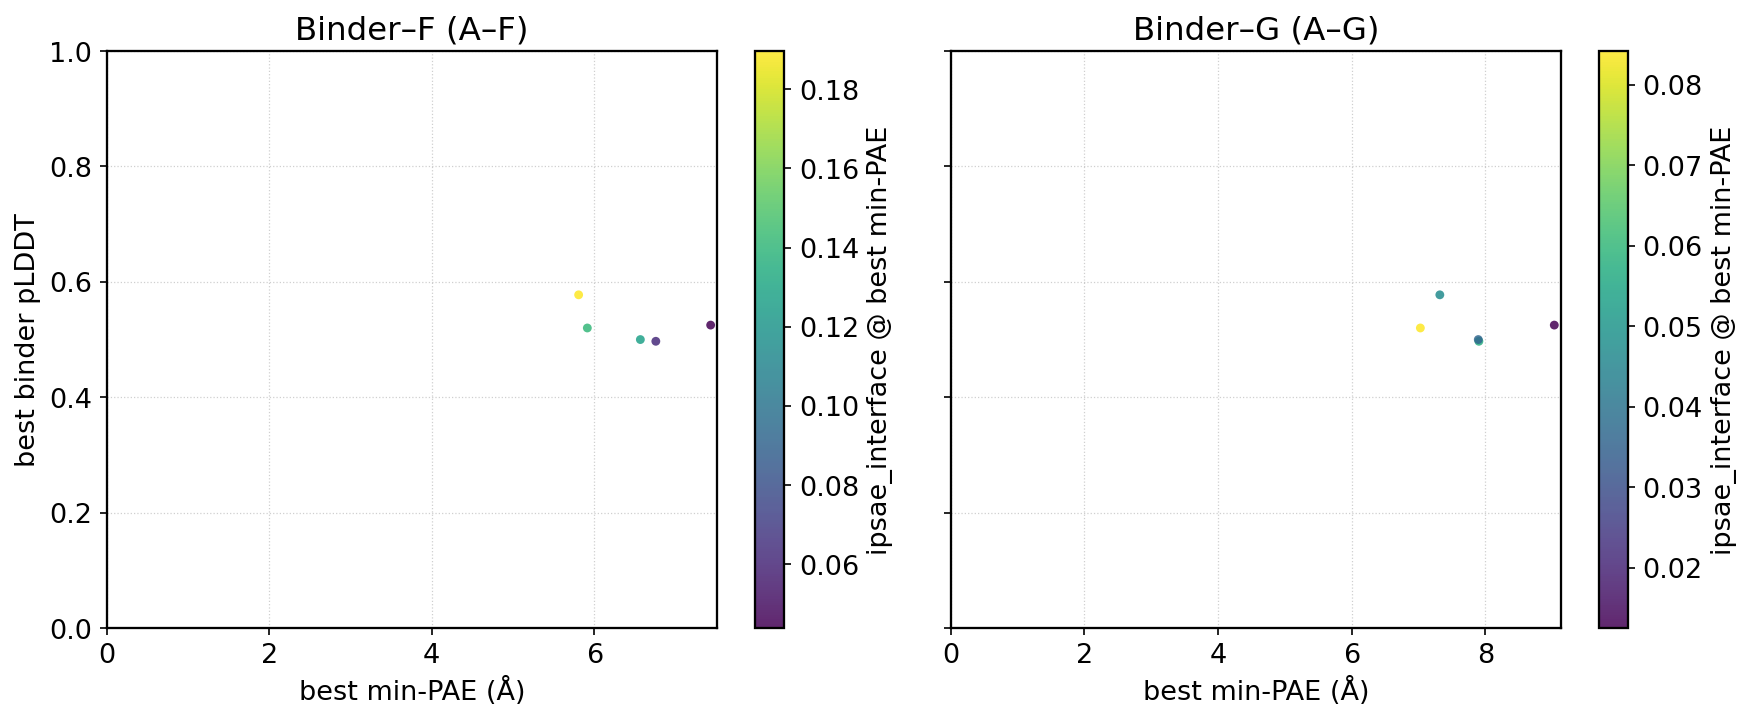

In [111]:
df = df_rf3

# --- pull arrays ---
y = df["best_binder_plddt"].to_numpy(float)

x_af = df["AF_best_min_pae"].to_numpy(float)
c_af = df["AF_ipsae_at_best"].to_numpy(float)

x_ag = df["AG_best_min_pae"].to_numpy(float)
c_ag = df["AG_ipsae_at_best"].to_numpy(float)

mask_af = np.isfinite(x_af) & np.isfinite(y) & np.isfinite(c_af)
mask_ag = np.isfinite(x_ag) & np.isfinite(y) & np.isfinite(c_ag)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 13,
    "axes.linewidth": 1.1,
    "figure.dpi": 150,
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left: Binder–F (A–F)
sc1 = axes[0].scatter(
    x_af[mask_af], y[mask_af],
    c=c_af[mask_af], s=18, alpha=0.85, linewidths=0,
    cmap="viridis"
)
axes[0].set_title("Binder–F (A–F)")
axes[0].set_xlabel("best min-PAE (Å)")
axes[0].set_ylabel("best binder pLDDT")
axes[0].grid(True, linestyle=":", linewidth=0.6, alpha=0.6)
cbar1 = fig.colorbar(sc1, ax=axes[0])
cbar1.set_label("ipsae_interface @ best min-PAE")

# Right: Binder–G (A–G)
sc2 = axes[1].scatter(
    x_ag[mask_ag], y[mask_ag],
    c=c_ag[mask_ag], s=18, alpha=0.85, linewidths=0,
    cmap="viridis"
)
axes[1].set_title("Binder–G (A–G)")
axes[1].set_xlabel("best min-PAE (Å)")
axes[1].grid(True, linestyle=":", linewidth=0.6, alpha=0.6)
cbar2 = fig.colorbar(sc2, ax=axes[1])
cbar2.set_label("ipsae_interface @ best min-PAE")

for ax in axes:
    ax.set_xlim(left=0)
    ax.set_ylim(0, 1.0)

fig.tight_layout()
plt.show()